# ECoG-Only PatchTSTClassifier

This notebook is structured for an ECoG-only seizure classifier using PatchTST. It is being built section by section.

## Imports

In [1]:
from pathlib import Path
import math
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm
from transformers import PatchTSTConfig, PatchTSTForClassification


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the Data Using `Final_Code/Data_Preprocessing/ecog_data_split.ipynb`

In [3]:
import torch
import numpy as np

# Load the saved file
data = torch.load("/content/drive/My Drive/Final_Code/Data_Preprocessing/ecog_tensors.pt", weights_only=False)

# Extract tensors
x_ecog_train = data["X_train"]   # shape: (N, 1600, 1)
y_ecog_train = data["y_train"]
x_ecog_val   = data["X_valid"]
y_ecog_val   = data["y_valid"]
x_ecog_test  = data["X_test"]
y_ecog_test  = data["y_test"]


# Print shapes to verify
print("Training shape X:", x_ecog_train.shape, "y:", y_ecog_train.shape)
print("Validation shape X:", x_ecog_val.shape, "y:", y_ecog_val.shape)
print("Test shape X:", x_ecog_test.shape, "y:", y_ecog_test.shape)

Training shape X: (7008, 3, 1600) y: (7008,)
Validation shape X: (1401, 3, 1600) y: (1401,)
Test shape X: (935, 3, 1600) y: (935,)


In [4]:
def _label_counts(y: np.ndarray) -> dict:
    labels, counts = np.unique(y, return_counts=True)
    return dict(zip(labels.tolist(), counts.tolist()))

## 2. Training & Hyperparameter Tuning

### Workflow of Training:

- `normalize_ecog_split(x)`: standardizes each split using only the training-set mean and standard deviation. We use it to keep the signal scale stable for optimization and to avoid leaking validation or test statistics into training. (This may be removed if the files are already normalized/for ecog it isn't)

- `to_patchtst_layout(x)`: converts the data from `(N, channels, time)` to `(N, time, channels)`. We use it because PatchTST expects the time dimension before the channel dimension.

- `EcogPatchTSTDataset`: packages one sample and its label into the format expected by the model. We use it so PyTorch can read the ECoG arrays sample by sample in a clean way.

- `DataLoader`: groups samples into batches for training and evaluation. We use it to feed the model efficiently instead of sending one sample at a time.

- `WeightedRandomSampler`: gives more sampling weight to the minority class. We use it because seizure samples are usually less frequent than non-seizure samples, and without rebalancing the model can become biased toward predicting class `0`.

- `FocalLoss`: modifies cross-entropy so hard or misclassified examples matter more than easy examples. We use it to make the model focus more on rare seizure examples and less on already-easy majority-class examples.
- `extract_logits(outputs)`: pulls the classification logits from the model output object. We use it so the notebook remains robust to small output-format differences.

- `compute_metrics_from_probs(y_true, y_prob, threshold)`: converts probabilities into class predictions and computes accuracy, precision, recall, and F1-score. We use it to compare model quality at a chosen threshold.

- `evaluate_probabilities(model, loader, loss_fn=None)`: runs the model on a full split and returns the true labels, seizure probabilities, and optional average loss. We use it to evaluate validation behavior, tune thresholds, and prepare later evaluation metrics.

- `tune_threshold(y_true, y_prob)`: searches for the probability threshold that gives the best validation F1-score. We use it because the best seizure-detection threshold is often not exactly `0.50`.

- `build_patchtst_model(run_params)`: creates one PatchTST classification model from a hyperparameter configuration. We use it to instantiate each candidate model in the search.

- `train_one_configuration(config_name, run_params)`: trains one hyperparameter setting, applies early stopping, and keeps the best validation checkpoint for that run. We use it to compare several candidate PatchTST configurations and select the best ECoG-only model.


In [5]:
# This section trains an ECoG-only PatchTST classifier and selects the
# best hyperparameter configuration using the validation split.
# Hugging Face exposes the classifier model as PatchTSTForClassification.


required_vars = [
    "x_ecog_train",
    "y_ecog_train",
    "x_ecog_val",
    "y_ecog_val",
    "x_ecog_test",
    "y_ecog_test",
]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing section 1 outputs: {missing_vars}. Run the data-loading cell first."
    )


SEED = 42
TRAIN_BATCH_SIZE = 64 #For safer memory usage for the gpu
EVAL_BATCH_SIZE = 128
EARLY_STOPPING_PATIENCE = 4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")


# Normalize using training statistics only.
# Change this preprocessing block if the input arrays later arrive pre-normalized.
train_mean_ecog = x_ecog_train.mean(axis=0, keepdims=True)
train_std_ecog = x_ecog_train.std(axis=0, keepdims=True) + 1e-8


def normalize_ecog_split(x: np.ndarray) -> np.ndarray:
    return ((x - train_mean_ecog) / train_std_ecog).astype(np.float32)


x_ecog_train_norm = normalize_ecog_split(x_ecog_train)
x_ecog_val_norm = normalize_ecog_split(x_ecog_val)
x_ecog_test_norm = normalize_ecog_split(x_ecog_test)


def to_patchtst_layout(x: np.ndarray) -> np.ndarray:
    return np.transpose(x, (0, 2, 1)).astype(np.float32)  # Change this transpose if the raw data shape stops being (N, channels, time).


class EcogPatchTSTDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.tensor(to_patchtst_layout(x), dtype=torch.float32)
        self.y = torch.tensor(y.astype(np.int64), dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> dict:
        return {
            "past_values": self.x[idx],
            "labels": self.y[idx],
        }


train_ds_ecog = EcogPatchTSTDataset(x_ecog_train_norm, y_ecog_train)
val_ds_ecog = EcogPatchTSTDataset(x_ecog_val_norm, y_ecog_val)
test_ds_ecog = EcogPatchTSTDataset(x_ecog_test_norm, y_ecog_test)

train_label_counts = _label_counts(y_ecog_train)
sample_weights = np.array([1.0 / train_label_counts[int(label)] for label in y_ecog_train], dtype=np.float64)
train_sampler_ecog = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader_ecog = DataLoader(train_ds_ecog, batch_size=TRAIN_BATCH_SIZE, sampler=train_sampler_ecog)
val_loader_ecog = DataLoader(val_ds_ecog, batch_size=EVAL_BATCH_SIZE, shuffle=False)
test_loader_ecog = DataLoader(test_ds_ecog, batch_size=EVAL_BATCH_SIZE, shuffle=False)

context_length_ecog = x_ecog_train_norm.shape[-1]  # Change this assumption if the sequence length changes from 1600.
num_channels_ecog = x_ecog_train_norm.shape[1]  # Change this assumption if the number of ECoG channels changes from 3.

print("Normalized splits ready for PatchTST:")
print(" - train:", train_ds_ecog.x.shape, train_label_counts)
print(" - val  :", val_ds_ecog.x.shape, _label_counts(y_ecog_val))
print(" - test :", test_ds_ecog.x.shape, _label_counts(y_ecog_test))
print(f" - context_length_ecog={context_length_ecog}, num_channels_ecog={num_channels_ecog}")


patchtst_hparam_grid = {
    "light": {
        "patch_length": 16,
        "d_model": 128,
        "num_attention_heads": 4,
        "num_hidden_layers": 3,
        "ffn_dim": 256,
        "dropout": 0.10,
        "head_dropout": 0.10,
        "learning_rate": 1e-4,
        "weight_decay": 1e-2,
        "epochs": 12,
        "focal_gamma": 2.0,
    },
    "medium": {
        "patch_length": 32,
        "d_model": 256,
        "num_attention_heads": 8,
        "num_hidden_layers": 4,
        "ffn_dim": 512,
        "dropout": 0.10,
        "head_dropout": 0.10,
        "learning_rate": 1e-4,
        "weight_decay": 1e-2,
        "epochs": 12,
        "focal_gamma": 2.0,
    },
}


class FocalLoss(nn.Module):
    def __init__(
        self,
        gamma: float = 2.0,
        class_weights: torch.Tensor | None = None,
        pos_weight: torch.Tensor | None = None,
    ):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights
        self.pos_weight = pos_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Some PatchTST builds emit one logit for binary classification,
        # while others emit two class logits. Handle both safely.
        if logits.ndim == 1:
            logits = logits.unsqueeze(-1)

        if logits.ndim == 2 and logits.shape[1] == 1:
            logits_pos = logits.squeeze(-1)
            bce = F.binary_cross_entropy_with_logits(
                logits_pos,
                targets.float(),
                pos_weight=self.pos_weight,
                reduction="none",
            )
            pt = torch.exp(-bce)
            return (((1.0 - pt) ** self.gamma) * bce).mean()

        ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce)
        return (((1.0 - pt) ** self.gamma) * ce).mean()


def extract_logits(outputs) -> torch.Tensor:
    if hasattr(outputs, "prediction_logits"):
        return outputs.prediction_logits
    if hasattr(outputs, "logits"):
        return outputs.logits
    return outputs[0]


def positive_class_probabilities(logits: torch.Tensor) -> torch.Tensor:
    if logits.ndim == 1:
        return torch.sigmoid(logits)
    if logits.ndim == 2 and logits.shape[1] == 1:
        return torch.sigmoid(logits.squeeze(-1))
    if logits.ndim == 2 and logits.shape[1] >= 2:
        return torch.softmax(logits, dim=1)[:, 1]
    raise ValueError(f"Unexpected logits shape for binary classification: {tuple(logits.shape)}")


def compute_metrics_from_probs(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def evaluate_probabilities(model: nn.Module, loader: DataLoader, loss_fn: nn.Module | None = None):
    model.eval()
    all_probs, all_labels = [], []
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            xb = batch["past_values"].to(device)
            yb = batch["labels"].to(device)

            outputs = model(past_values=xb)
            logits = extract_logits(outputs)
            probs = positive_class_probabilities(logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

            if loss_fn is not None:
                batch_loss = loss_fn(logits, yb)
                total_loss += float(batch_loss.item()) * xb.size(0)
                total_count += xb.size(0)

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    avg_loss = (total_loss / total_count) if total_count > 0 else None
    return y_true, y_prob, avg_loss


def tune_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> tuple[float, dict]:
    best_threshold = 0.5
    best_metrics = compute_metrics_from_probs(y_true, y_prob, threshold=0.5)

    for threshold in np.arange(0.05, 0.951, 0.01):
        metrics = compute_metrics_from_probs(y_true, y_prob, threshold=float(threshold))
        if metrics["f1"] > best_metrics["f1"]:
            best_threshold = float(threshold)
            best_metrics = metrics

    return best_threshold, best_metrics


def build_patchtst_model(run_params: dict) -> PatchTSTForClassification:
    config = PatchTSTConfig(
        context_length=context_length_ecog,  # Change this if the sequence length changes.
        num_input_channels=num_channels_ecog,  # Change this if the number of channels changes.
        num_classes=2,
        patch_length=run_params["patch_length"],
        d_model=run_params["d_model"],
        num_attention_heads=run_params["num_attention_heads"],
        num_hidden_layers=run_params["num_hidden_layers"],
        ffn_dim=run_params["ffn_dim"],
        dropout=run_params["dropout"],
        head_dropout=run_params["head_dropout"],
    )
    return PatchTSTForClassification(config)


import os
import torch
from torch.cuda.amp import autocast, GradScaler

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

TRAIN_BATCH_SIZE = 32   # ↓ reduced to avoid OOM
EVAL_BATCH_SIZE = 64
ACCUM_STEPS = 2         # gradient accumulation
USE_AMP = True          # mixed precision

scaler = GradScaler(enabled=USE_AMP)


def train_one_configuration(config_name: str, run_params: dict) -> dict:
    print(f"\n=== Training configuration: {config_name} ===")

    torch.cuda.empty_cache()  # ✅ prevent memory buildup

    model = build_patchtst_model(run_params).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=run_params["learning_rate"],
        weight_decay=run_params["weight_decay"],
    )

    class_counts = _label_counts(y_ecog_train)
    total_count = sum(class_counts.values())

    class_weights = torch.tensor(
        [total_count / (2.0 * class_counts[0]), total_count / (2.0 * class_counts[1])],
        dtype=torch.float32,
        device=device,
    )

    pos_weight = torch.tensor(
        class_counts[0] / class_counts[1],
        dtype=torch.float32,
        device=device,
    )

    loss_fn = FocalLoss(
        gamma=run_params["focal_gamma"],
        class_weights=class_weights,
        pos_weight=pos_weight,
    )

    history = []
    best_state_dict = None
    best_threshold = 0.5
    best_val_metrics = {"accuracy": 0.0, "precision": 0.0, "recall": 0.0, "f1": -1.0}
    best_val_loss = None
    epochs_without_improvement = 0

    for epoch in range(1, run_params["epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        running_loss = 0.0
        sample_count = 0

        for step, batch in enumerate(train_loader_ecog):
            xb = batch["past_values"].to(device)
            yb = batch["labels"].to(device)

            with autocast(enabled=USE_AMP):
                outputs = model(past_values=xb)
                logits = extract_logits(outputs)
                loss = loss_fn(logits, yb)
                loss = loss / ACCUM_STEPS  # ✅ gradient accumulation

            scaler.scale(loss).backward()

            if (step + 1) % ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            running_loss += float(loss.item()) * xb.size(0)
            sample_count += xb.size(0)

        train_loss = running_loss / max(sample_count, 1)

        # ===== Validation =====
        y_val_true, y_val_prob, val_loss = evaluate_probabilities(
            model, val_loader_ecog, loss_fn=loss_fn
        )

        tuned_threshold, val_metrics = tune_threshold(y_val_true, y_val_prob)

        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={(f'{val_loss:.4f}' if val_loss is not None else 'None')} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"thr={tuned_threshold:.2f}"
        )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss) if val_loss else None,
            "val_f1": float(val_metrics["f1"]),
        })

        # ===== Best model tracking =====
        if val_metrics["f1"] > best_val_metrics["f1"]:
            best_val_metrics = val_metrics
            best_threshold = tuned_threshold
            best_val_loss = val_loss

            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping for {config_name}")
                break

    if best_state_dict is None:
        raise RuntimeError(f"No best model for {config_name}")

    # ===== Reload best model =====
    best_model = build_patchtst_model(run_params)
    best_model.load_state_dict(best_state_dict)
    best_model.to(device)
    best_model.eval()

    # ===== SAVE MODEL (both formats) =====
    save_path = os.path.join(SAVE_DIR, config_name)

    # Hugging Face format
    best_model.save_pretrained(save_path)

    # PyTorch weights
    torch.save(best_state_dict, os.path.join(SAVE_DIR, f"{config_name}.pt"))

    # Metadata
    torch.save({
        "config": run_params,
        "threshold": best_threshold,
        "metrics": best_val_metrics,
    }, os.path.join(SAVE_DIR, f"{config_name}_meta.pt"))

    print(f"✅ Saved model: {config_name} → {save_path}")

    return {
        "config_name": config_name,
        "config": run_params,
        "model": best_model,
        "history": history,
        "best_threshold": best_threshold,
        "best_val_metrics": best_val_metrics,
    }


Training device: cuda
Normalized splits ready for PatchTST:
 - train: torch.Size([7008, 1600, 3]) {0: 3953, 1: 3055}
 - val  : torch.Size([1401, 1600, 3]) {0: 790, 1: 611}
 - test : torch.Size([935, 1600, 3]) {0: 528, 1: 407}
 - context_length_ecog=1600, num_channels_ecog=3


/tmp/ipykernel_4720/1540017567.py:264: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


In [6]:
training_runs_ecog = {}
best_model = None
best_val_score = -1
best_config_name = None

for config_name, run_params in patchtst_hparam_grid.items():
    result = train_one_configuration(config_name, run_params)

    training_runs_ecog[config_name] = result

    if result["best_val_metrics"]["f1"] > best_val_score:
        best_val_score = result["best_val_metrics"]["f1"]
        best_model = result["model"]
        best_config_name = config_name

print("\n🏆 BEST CONFIG:", best_config_name)


=== Training configuration: light ===


/tmp/ipykernel_4720/1540017567.py:319: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: train_loss=0.1082 | val_loss=0.2001 | val_f1=0.7408 | thr=0.54


/tmp/ipykernel_4720/1540017567.py:319: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 2: train_loss=0.0895 | val_loss=0.1647 | val_f1=0.7892 | thr=0.51


...

Epoch 11: train_loss=0.0327 | val_loss=0.0924 | val_f1=0.8925 | thr=0.57


/tmp/ipykernel_4720/1540017567.py:319: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 12: train_loss=0.0319 | val_loss=0.0954 | val_f1=0.9027 | thr=0.52


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved model: medium → saved_models/medium

🏆 BEST CONFIG: medium


In [7]:
import shutil
import os

# Path to your current saved_models folder
local_saved_models = "saved_models"

# Path in your Google Drive
drive_path = "/content/drive/MyDrive/Final_Code/patchtst_ecog_only_models"

# Create the target folder if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# Copy all models to Drive
shutil.copytree(local_saved_models, drive_path, dirs_exist_ok=True)

print(f"✅ Models copied to Google Drive: {drive_path}")

✅ Models copied to Google Drive: /content/drive/MyDrive/Final_Code/patchtst_ecog_only_models


## 3. Evaluation

In [8]:
# ===== EVALUATE THE TRAINED MODEL =====

# Default threshold for binary predictions
threshold_used = 0.5

# Loaders for each split
split_loaders_ecog = {
    "train": train_loader_ecog,
    "val": val_loader_ecog,
    "test": test_loader_ecog,
}

# Dictionaries to store outputs and summary metrics
evaluation_outputs_ecog = {}
evaluation_summary_ecog = {}

# Make sure model is on the correct device
best_model.to(device)
best_model.eval()

for split_name, split_loader in split_loaders_ecog.items():
    # Get probabilities, labels, and loss
    y_true_split, y_prob_split, split_loss = evaluate_probabilities(best_model, split_loader)

    # Compute metrics at default threshold 0.5
    metrics_at_threshold = compute_metrics_from_probs(y_true_split, y_prob_split, threshold=threshold_used)

    # Store full outputs for later analysis
    evaluation_outputs_ecog[split_name] = {
        "y_true": y_true_split,
        "y_prob": y_prob_split,
        "y_pred": (y_prob_split >= threshold_used).astype(int),
        "loss": float(split_loss) if split_loss is not None else None,
    }

    # Store summary metrics for easy printing
    evaluation_summary_ecog[split_name] = {
        "threshold_used": threshold_used,
        "loss": float(split_loss) if split_loss is not None else None,
        "metrics": metrics_at_threshold,
        "num_samples": int(len(y_true_split)),
        "label_counts": _label_counts(y_true_split),
    }

# ===== PRINT SUMMARY =====
print("✅ Evaluation completed using the trained model (threshold=0.5)")

for split_name, split_summary in evaluation_summary_ecog.items():
    metrics = split_summary["metrics"]
    print(f"\n[{split_name.upper()}]")
    print(f" - samples: {split_summary['num_samples']}")
    print(f" - label_counts: {split_summary['label_counts']}")
    if split_summary['loss'] is not None:
        print(f" - loss: {split_summary['loss']:.4f}")
    print(
        f" - metrics @ threshold {threshold_used:.2f}: "
        f"accuracy={metrics['accuracy']:.4f}, "
        f"precision={metrics['precision']:.4f}, "
        f"recall={metrics['recall']:.4f}, "
        f"f1={metrics['f1']:.4f}"
    )

✅ Evaluation completed using the trained model (threshold=0.5)

[TRAIN]
 - samples: 7008
 - label_counts: {0: 3559, 1: 3449}
 - metrics @ threshold 0.50: accuracy=0.9341, precision=0.9213, recall=0.9469, f1=0.9339

[VAL]
 - samples: 1401
 - label_counts: {0: 790, 1: 611}
 - metrics @ threshold 0.50: accuracy=0.9108, precision=0.8809, recall=0.9198, f1=0.8999

[TEST]
 - samples: 935
 - label_counts: {0: 528, 1: 407}
 - metrics @ threshold 0.50: accuracy=0.9155, precision=0.9080, recall=0.8968, f1=0.9023



[TRAIN] Metrics @ threshold 0.5
Accuracy: 0.9307
Precision: 0.9214
Recall: 0.9419
F1: 0.9315
AUC-ROC: 0.9790
AUPRC: 0.9784
Confusion Matrix:
[[3217  282]
 [ 204 3305]]


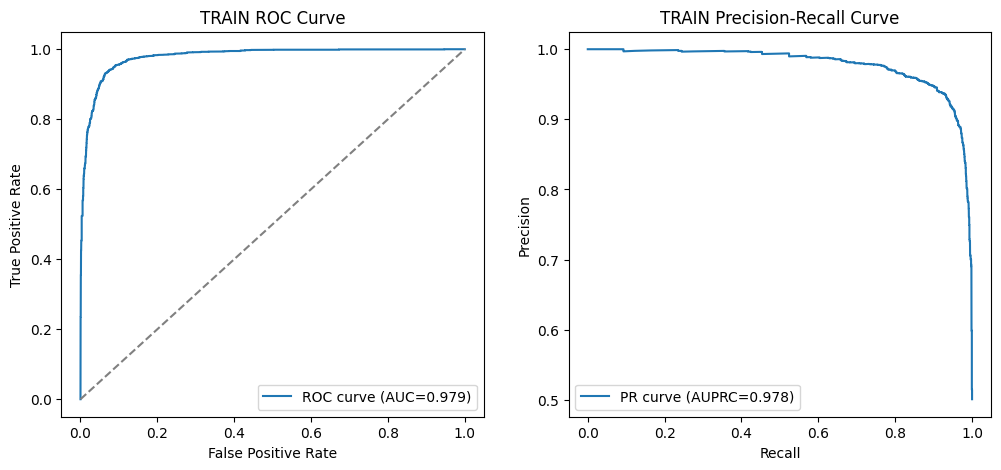


[VAL] Metrics @ threshold 0.5
Accuracy: 0.9108
Precision: 0.8809
Recall: 0.9198
F1: 0.8999
AUC-ROC: 0.9646
AUPRC: 0.9535
Confusion Matrix:
[[714  76]
 [ 49 562]]


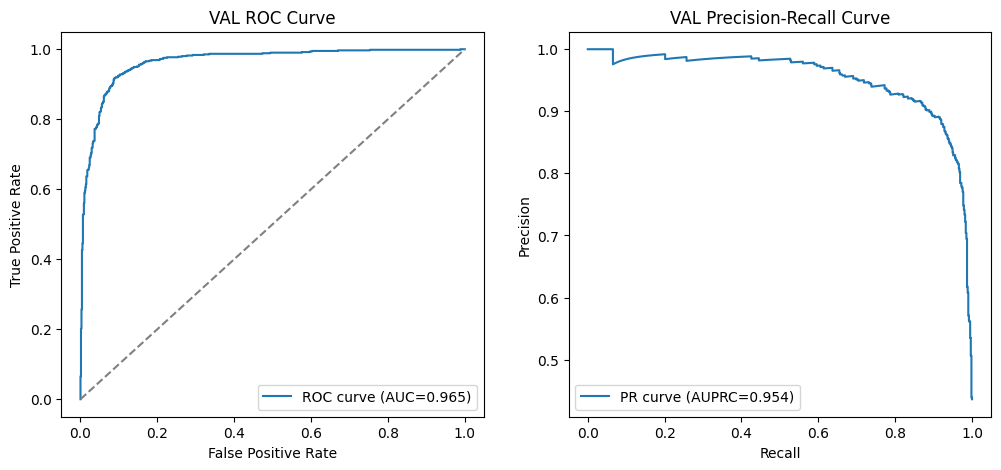


[TEST] Metrics @ threshold 0.5
Accuracy: 0.9155
Precision: 0.9080
Recall: 0.8968
F1: 0.9023
AUC-ROC: 0.9702
AUPRC: 0.9662
Confusion Matrix:
[[491  37]
 [ 42 365]]


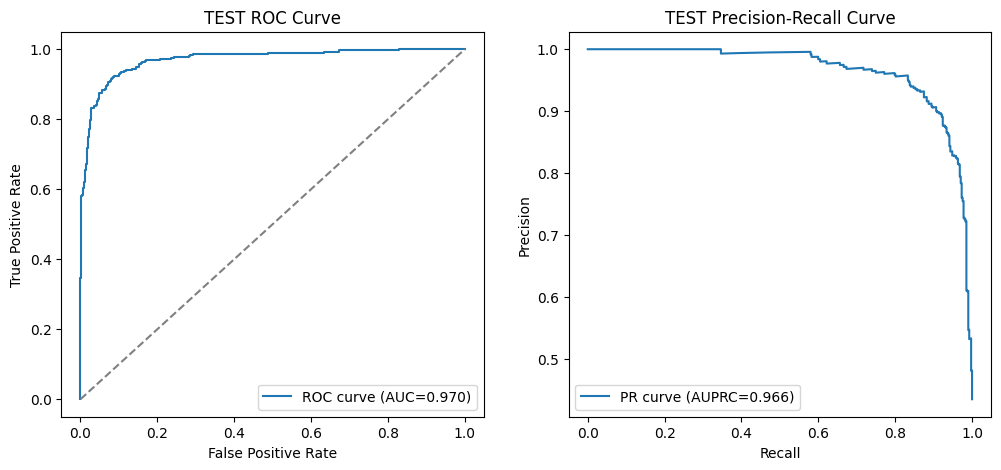

In [9]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
import matplotlib.pyplot as plt

# --- Make sure your model is loaded and on device ---
best_model.to(device)
best_model.eval()

# --- Helper to get probabilities and labels ---
def get_probs_and_labels(model, loader):
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            xb = batch["past_values"].to(device)
            yb = batch["labels"].to(device)
            outputs = model(past_values=xb)
            # extract logits safely
            logits = outputs.prediction_logits if hasattr(outputs, "prediction_logits") else outputs.logits
            # get positive class probability
            if logits.shape[1] == 1:
                probs = torch.sigmoid(logits).squeeze(-1)
            else:
                probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.cpu().numpy())
            all_labels.append(yb.cpu().numpy())
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    return y_true, y_prob

# --- Compute metrics given true labels and predicted probabilities ---
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "roc_curve": roc_curve(y_true, y_prob),  # returns fpr, tpr, thresholds
        "pr_curve": precision_recall_curve(y_true, y_prob),  # returns precision, recall, thresholds
    }
    return metrics

# --- Evaluate each split ---
splits = {"train": train_loader_ecog, "val": val_loader_ecog, "test": test_loader_ecog}
all_metrics = {}

for split_name, loader in splits.items():
    y_true, y_prob = get_probs_and_labels(best_model, loader)
    metrics = compute_all_metrics(y_true, y_prob, threshold=0.5)
    all_metrics[split_name] = metrics
    print(f"\n[{split_name.upper()}] Metrics @ threshold 0.5")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1: {metrics['f1']:.4f}")
    print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
    print(f"AUPRC: {metrics['auprc']:.4f}")
    print("Confusion Matrix:")
    print(metrics["confusion_matrix"])

    # Plot ROC and PR curves
    fpr, tpr, _ = metrics["roc_curve"]
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"ROC curve (AUC={metrics['auc_roc']:.3f})")
    plt.plot([0,1],[0,1],"--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.upper()} ROC Curve")
    plt.legend()

    precision, recall, _ = metrics["pr_curve"]
    plt.subplot(1,2,2)
    plt.plot(recall, precision, label=f"PR curve (AUPRC={metrics['auprc']:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{split_name.upper()} Precision-Recall Curve")
    plt.legend()
    plt.show()